In [1]:
import numpy as np
import pandas as pd
from pylab import *
import seaborn as sns
import pickle
import matplotlib.pyplot as plt
import pandas as pd
from pylab import *
from sequana import FastA
import tensorflow as tf
from tensorflow.keras import layers, models
from tqdm import tqdm
from sklearn.model_selection import train_test_split

import random
from collections import defaultdict
from sklearn.metrics import classification_report


2025-07-29 09:22:22.362847: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-29 09:22:23.626415: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-29 09:22:24.470520: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753773745.010639    4667 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753773745.158044    4667 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753773746.475829    4667 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [2]:
centromeres = pd.read_csv("../../output/estimation/major/Major.csv")
centromeres = {
    str(row['Chromosome']): (row['start'], row['end'])
    for _, row in centromeres.iterrows()
}


In [3]:
f = FastA("../../data/Fasta/TriTrypDB-68_LmajorFriedlin_Genome.fasta")

In [4]:
def one_hot_encoding(x):
    if x == 'A':
        return np.array([1,0,0,0])
    elif x == 'C':
        return np.array([0,1,0,0])
    elif x == 'G':
        return np.array([0,0,1,0])
    elif x == 'T':
        return np.array([0,0,0,1])
    else:
        return np.array([0,0,0,0])
        

In [5]:
SIZE=3000

In [6]:
def get_true_positive(size=3000):
    data = []
    for chrom in range(1,36+1):
        start, stop = centromeres[str(chrom)]
        #seq = f.sequences[f.names.index(str(chrom))]
        seq = f.sequences[chrom-1]

        if stop-start != 3000:
            stop = start + size
        # flip to get more positives
        data.append([one_hot_encoding(x) for x in seq[start:stop]])
        data.append([one_hot_encoding(x) for x in seq[start:stop][::-1]])
        

    return data
positives = get_true_positive(SIZE)

In [7]:
lengths = list(f.get_lengths_as_dict().values())

In [8]:

##################################### WARNING #############################################
############################### REMOVE FALSE NEGATIVE (centromeres) #######################

def get_true_negatives(N=1000,size=3000,seed=42):
    data = []
    positions = defaultdict(list)
    random.seed(seed)

    # get the random combos first
    for i in tqdm(range(N)):
        chrom = random.randint(1,36)
        N = lengths[chrom-1]
        pos = random.randint(1, N-size)
        start, stop = centromeres[str(chrom)]
        if pos>start and pos<stop:
            pass # this is a centromeres so not a negative
        else:
            positions[chrom].append(pos)
        
        
    for chrom in tqdm(positions.keys()):
        seq = f.sequences[chrom-1]
        for position in positions[chrom]:
            data.append([one_hot_encoding(x) for x in seq[position:position+size]])
    return data

    #negatives = get_true_negatives(N=10000, size=SIZE)

In [9]:
f = FastA("../../data/Fasta/TriTrypDB-68_LmajorFriedlin_Genome.fasta")

negatives = get_true_negatives(N=10000, size=SIZE,seed=1)


X_pos = positives
X_neg = negatives


# Create label arrays
y_pos = [1] * len(X_pos)
y_neg = [0] * len(X_neg)

# Combine and shuffle
X = np.array(X_pos + X_neg)  # shape: (N, 3000, 4)
y = np.array(y_pos + y_neg)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


layer_size=16

model = models.Sequential([
    layers.Input(shape=(SIZE, 4)),
    layers.Conv1D(layer_size,15, activation='relu'),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(layer_size*2, 10, activation='relu'),
    layers.GlobalMaxPooling1D(),
    layers.Dense(layer_size, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # binary classification
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

seed = 42

tf.random.set_seed(seed)

tf.config.experimental.enable_op_determinism()
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=40,
    batch_size=32,
    class_weight={0: 1, 1: len(y_neg)/len(y_pos)},  # handle imbalance
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)]
)


y_pred = model.predict(X_test) > 0.2
report = classification_report(y_test, y_pred, output_dict=True)

metrics = {
    'f1_score': report['1']['f1-score'],
    'precision': report['1']['precision'],
    'recall': report['1']['recall']
}




100%|███████████████████████████████████████████| 36/36 [00:31<00:00,  1.13it/s]
2025-07-29 09:23:21.830714: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/40


2025-07-29 09:23:23.490969: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


250/251 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.7050 - loss: 1.3960

2025-07-29 09:23:38.130502: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


251/251 ━━━━━━━━━━━━━━━━━━━━ 16s 54ms/step - accuracy: 0.7042 - loss: 1.3960 - val_accuracy: 0.1786 - val_loss: 0.7323
Epoch 2/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 14s 55ms/step - accuracy: 0.6327 - loss: 1.2104 - val_accuracy: 0.6322 - val_loss: 0.6661
Epoch 3/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 14s 55ms/step - accuracy: 0.7991 - loss: 0.9657 - val_accuracy: 0.8668 - val_loss: 0.4096
Epoch 4/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 21s 55ms/step - accuracy: 0.9069 - loss: 0.6093 - val_accuracy: 0.9736 - val_loss: 0.1298
Epoch 5/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - accuracy: 0.9541 - loss: 0.3415 - val_accuracy: 0.9671 - val_loss: 0.1201
Epoch 6/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.9770 - loss: 0.1754 - val_accuracy: 0.9641 - val_loss: 0.1144
Epoch 7/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.9834 - loss: 0.0993 - val_accuracy: 0.9775 - val_loss: 0.0787
Epoch 8/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.9851 - loss: 0.0803 - val_accurac

2025-07-29 09:29:55.063553: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


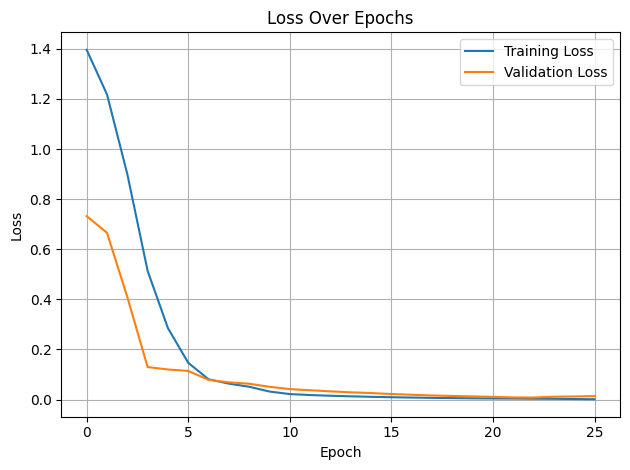

In [10]:
import matplotlib.pyplot as plt


# Plot training & validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


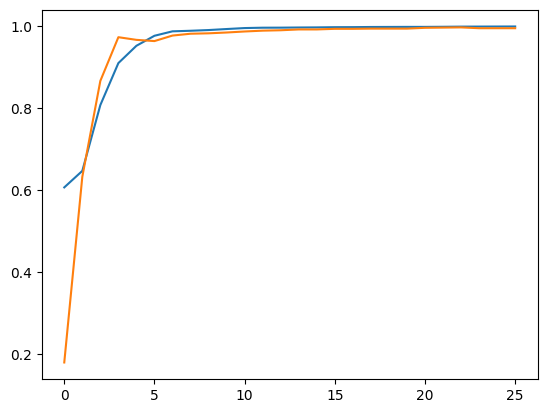

In [11]:
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


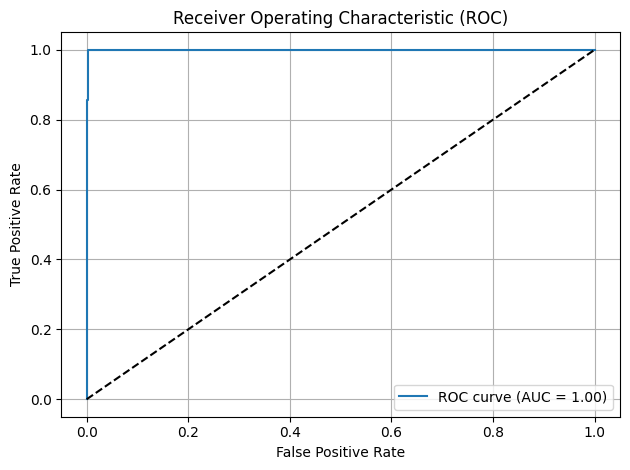

In [12]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities
y_prob = model.predict(X_test).ravel()  # get raw probabilities

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC
plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


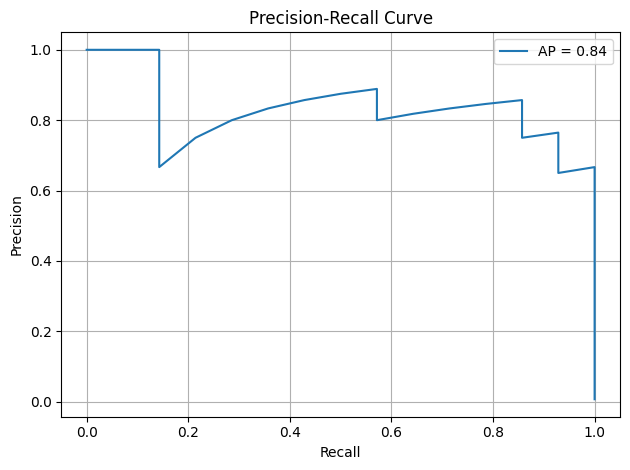

In [13]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, y_prob)
avg_prec = average_precision_score(y_test, y_prob)

plt.plot(recall, precision, label=f'AP = {avg_prec:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [14]:
import numpy as np

def predict_sliding_windows(seq, model, window_size=3000, step=1500):
    
    scores = []
    positions = []

    # Slide through the sequence
    for i in tqdm(range(0, len(seq) - window_size + 1, step)):
        chunk = seq[i:i + window_size]
        
        # One-hot encoded? Already a list of np.array([1,0,0,0]) per base
        # Otherwise, if string-based: encode here
        chunk = [one_hot_encoding(x) for x in chunk]
        X = np.array(chunk).reshape(1, window_size, 4)  # batch of 1
        prob = model.predict(X, verbose=0)[0][0]
        
        scores.append(prob)
        positions.append((i, i + window_size))

    return positions, scores


In [15]:
all_scores = {}
results = {}


In [22]:
#f = FastA("../../data/Fasta/TriTrypDB-68_LmajorFriedlin_Genome.fasta")
#f = FastA("../../data/Fasta/genome.fasta")
f = FastA("../../data/Fasta/genomes/Lmexicana/ragtag.scaffold.fasta")

#centromeres = pd.read_csv("../../output/estimation/donovani/donovani_genome.csv")
centromeres = pd.read_csv("../../output/estimation/mexicana.csv")

#f = FastA("../../data/Fasta/genomes/Lmartiniquensis/ragtag.scaffold.fasta")
#centromeres = pd.read_csv("../../output/estimation/martiniquensis.csv")
centromeres = {
    str(row['Chromosome']): (row['start'], row['end'])
    for _, row in centromeres.iterrows()
}

for chrom in range(16,37):
    #f = FastA("LmajorFriedlin/LmajorFriedlin_genome.fasta")
            
    try:
        #seq = f.sequences[chrom-1]
        seq = f.sequences[f.names.index(str(chrom))]

    except:
        seq = f.sequences[chrom-1].upper().replace('N', 'T')
    clf()
    positions, scores = predict_sliding_windows(seq, model)
    _ = plot([x[0] for x in positions], scores)
    start, stop = centromeres[str(chrom)]
    axvline(start, color='r', alpha=0.5)
    axhline(0.2, color='g')
    savefig(f"./falsePosi/mexicana/CNN1_{chrom}_LMexicana.png")
    print(chrom, positions[argmax(scores)], max(scores))
    all_scores[chrom] = max(scores)

100%|█████████████████████████████████████████| 458/458 [00:40<00:00, 11.25it/s]


16 (331500, 334500) 0.9921052


100%|█████████████████████████████████████████| 442/442 [00:38<00:00, 11.58it/s]


17 (325500, 328500) 0.9202492


 15%|██████▍                                   | 71/461 [00:06<00:34, 11.33it/s]


KeyboardInterrupt: 

<Figure size 640x480 with 0 Axes>

  0%|                                           | 1/492 [00:00<00:52,  9.42it/s]

ERROR! Session/line number was not unique in database. History logging moved to new session 306


100%|█████████████████████████████████████████| 492/492 [00:41<00:00, 11.80it/s]


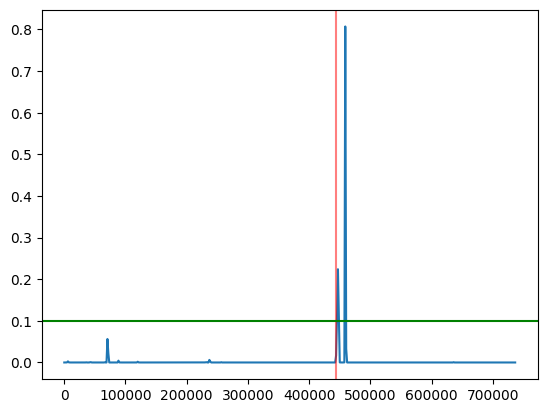

In [20]:
f = FastA("../../data/Fasta/TriTrypDB-68_LmajorFriedlin_Genome.fasta")

recherche = 18
for chrom in range(recherche,recherche+1):
    #f = FastA("LmajorFriedlin/LmajorFriedlin_genome.fasta")
            
    try:
        seq = f.sequences[chrom-1]
    except:
        seq = f.sequences[chrom-1].upper().replace('N', 'T')
    clf()
    positions, scores = predict_sliding_windows(seq, model)
    _ = plot([x[0] for x in positions], scores)
    start, stop = centromeres[str(chrom)]
    axvline(start, color='r', alpha=0.5)
    axhline(0.1, color='g')


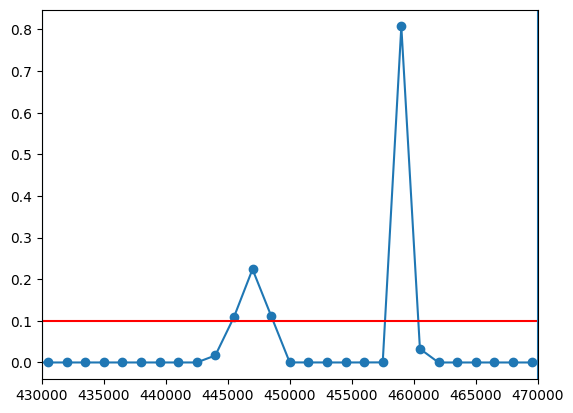

In [23]:
plot([x[0] for  x in positions], scores, 'o-')
xlim([430000,470000])
axhline(0.1, color='r')
axvline(430000)
axvline(470000)

100%|███████████████████████████████████████████| 75/75 [00:06<00:00, 11.99it/s]


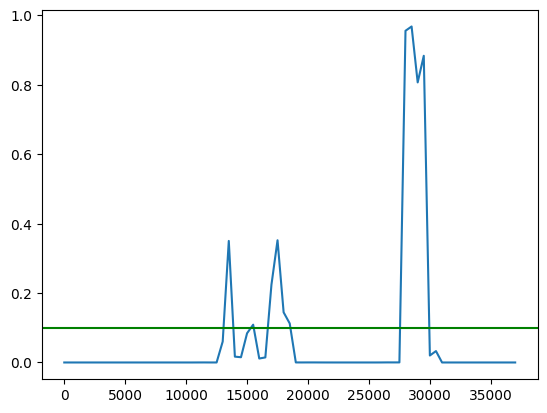

In [26]:
f = FastA("../../data/Fasta/TriTrypDB-68_LmajorFriedlin_Genome.fasta")

recherche = 18
for chrom in range(recherche,recherche+1):
    #f = FastA("LmajorFriedlin/LmajorFriedlin_genome.fasta")
            
    try:
        seq = f.sequences[chrom-1]
    except:
        seq = f.sequences[chrom-1].upper().replace('N', 'T')
    clf()
    seq = seq[430000:470000]
    positions, scores = predict_sliding_windows(seq, model,SIZE,500)
    _ = plot([x[0] for x in positions], scores)
    axhline(0.1, color='g')

In [ ]:
#f = FastA("../../data/Fasta/TriTrypDB-68_LmajorFriedlin_Genome.fasta")
f = FastA("../../data/Fasta/genome.fasta")

centromeres = pd.read_csv("../../output/estimation/donovani/donovani_genome.csv")
centromeres = {
    str(row['Chromosome']): (row['start'], row['end'])
    for _, row in centromeres.iterrows()
}

for chrom in range(1,37):
    #f = FastA("LmajorFriedlin/LmajorFriedlin_genome.fasta")
            
    try:
        seq = f.sequences[chrom-1]
    except:
        seq = f.sequences[chrom-1].upper().replace('N', 'T')
    clf()
    positions, scores = predict_sliding_windows(seq, model)
    _ = plot([x[0] for x in positions], scores)
    start, stop = centromeres[str(chrom)]
    axvline(start, color='r', alpha=0.5)
    axhline(0.1, color='g')
    savefig(f"./falsePosi/donovani/CNN1_{chrom}_Ldo.png")
    print(chrom, positions[argmax(scores)], max(scores))
    all_scores[chrom] = max(scores)